# FRED Data Acquisition
Pulling risk-free rate (3-month Treasury yield) and CPI from FRED for use in Sharpe ratio and macro context calculations.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from pandas_datareader import data as web


## Setup Paths and Date Range

FRED data is pulled with pandas-datareader, which can access public FRED series without requiring a local API key.


In [2]:
RAW_DATA_PATH = Path('../../data/raw/fred')
PROCESSED_DATA_PATH = Path('../../data/processed/fred')

RAW_DATA_PATH.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_PATH.mkdir(parents=True, exist_ok=True)

START_DATE = '2018-01-01'
END_DATE = '2025-12-31'


In [3]:
print('FRED data will be pulled from', START_DATE, 'to', END_DATE)


FRED data will be pulled from 2018-01-01 to 2025-12-31


## Pull risk-free rate (3-month Treasury yield)
Series ID: `DGS3MO` — the standard proxy for the risk-free rate in Sharpe ratio calculations.

In [4]:
rf_raw = web.DataReader('DGS3MO', 'fred', START_DATE, END_DATE)
rf_raw = rf_raw.rename(columns={'DGS3MO': 'risk_free_rate_pct'})
rf_raw.index.name = 'date'

print(f"Pulled {len(rf_raw)} rows")
print(f"Date range: {rf_raw.index.min()} to {rf_raw.index.max()}")
rf_raw.head()


Pulled 2088 rows
Date range: 2018-01-01 00:00:00 to 2025-12-31 00:00:00


,risk_free_rate_pct
date,
2018-01-01,NaN
2018-01-02,1.44
2018-01-03,1.41
2018-01-04,1.41
2018-01-05,1.39


## Pull CPI (optional macro context)
Series ID: `CPIAUCSL` — Consumer Price Index, monthly. Useful for inflation-adjusted context during the backtest period.

In [5]:
cpi_raw = web.DataReader('CPIAUCSL', 'fred', START_DATE, END_DATE)
cpi_raw = cpi_raw.rename(columns={'CPIAUCSL': 'cpi_index'})
cpi_raw.index.name = 'date'

print(f"Pulled {len(cpi_raw)} rows")
cpi_raw.head()


Pulled 96 rows


,cpi_index
date,
2018-01-01,248.859
2018-02-01,249.529
2018-03-01,249.577
2018-04-01,250.227
2018-05-01,250.792


## Quick sanity checks

Risk-free rate missing values: 89
CPI missing values: 1


<Axes: title={'center': '3-Month Treasury Yield (Raw)'}, xlabel='date'>

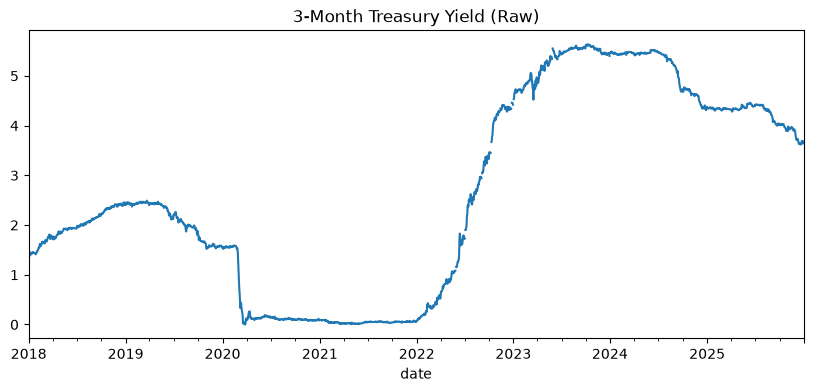

In [6]:
print("Risk-free rate missing values:", rf_raw['risk_free_rate_pct'].isna().sum())
print("CPI missing values:", cpi_raw['cpi_index'].isna().sum())

rf_raw['risk_free_rate_pct'].plot(title='3-Month Treasury Yield (Raw)', figsize=(10,4))

## Save raw data

In [7]:
rf_raw.to_csv(RAW_DATA_PATH / 'fred_risk_free_rate_raw.csv')
cpi_raw.to_csv(RAW_DATA_PATH / 'fred_cpi_raw.csv')

print("Saved raw FRED data to", RAW_DATA_PATH)

Saved raw FRED data to ..\..\data\raw\fred
